# **Proyecto 08: Sistema de Identificación de Especies de Aves con Imágenes y Deep Learning**

### Versión 2 — Modelo más potente (EfficientNetV2S) + fine-tuning robusto

---
## **Parte 1: Carga del data set**

Empezaremos cargando las imágenes de aves que formarán el dataset. Hay que tener en cuenta que las imágenes pueden tener tamaños distintos, así que vamos a fijar que todas ellas se deben convertir en imágenes de 256x256 píxeles y 3 canales.

In [1]:
# Definimos las dimensiones de las imágenes
IMG_ROWS = 256
IMG_COLS = 256
CHANNELS = 3
IMG_SHAPE = (IMG_ROWS, IMG_COLS, CHANNELS)

print(f"Las imágenes se redimensionarán a: {IMG_SHAPE}")

Las imágenes se redimensionarán a: (256, 256, 3)


Para cargar y procesar las imágenes de forma rápida y eficiente usamos la API moderna de **TensorFlow**: [**image_dataset_from_directory**](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory) junto con la API **tf.data**:

*   **Carga inicial**: Divide el dataset en entrenamiento (80%) y validación (20%), en modo categórico y por lotes.
*   **Data Augmentation**: Aplicamos sobre los tensores varias transformaciones para aumentar la variedad de los datos (`RandomFlip`, `RandomRotation`, `RandomZoom` y `RandomContrast`). Esta es una de nuestras principales defensas contra el overfitting.
*   **Optimización**: Con `.cache()`, `tf.data.AUTOTUNE` y `.prefetch()` la CPU prepara los siguientes lotes mientras la GPU entrena, sin cuellos de botella.

> **Importante:** no dividimos las imágenes por 255. El modelo preentrenado que usaremos (EfficientNetV2) incluye su propia capa de normalización interna y espera las imágenes en el rango original [0, 255].

In [2]:
from tensorflow.keras import mixed_precision

# Activamos precisión mixta global (acelera el entrenamiento en GPU)
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [3]:
import tensorflow as tf

# Directorio base donde están las carpetas de las clases de aves
data_dir = 'CUB_200_2011/images'

# EfficientNetV2S es más grande que B0: usamos un batch más pequeño.
# Si la GPU se queda sin memoria durante la Fase 2 (fine-tuning), baja a 8.
batch_size = 16
AUTOTUNE = tf.data.AUTOTUNE

# 1. Cargamos las imágenes de entrenamiento (80%)
raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=121,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=batch_size,
    label_mode='categorical'
)

# 2. Cargamos las imágenes de validación (20%)
raw_validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=121,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=batch_size,
    label_mode='categorical'
)

# Obtenemos el número de clases
num_classes = len(raw_train_dataset.class_names)

# Tareas de aumento de datos (más variedad = menos overfitting)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# IMPORTANTE: EfficientNetV2 espera las imágenes en rango [0, 255].
# Ya NO se divide por 255: la normalización va incluida dentro del modelo.
def prepare_train(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# 3. Optimización con tf.data
train_dataset = (
    raw_train_dataset
    .cache()
    .map(prepare_train, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

validation_dataset = (
    raw_validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print(f"Número de clases: {num_classes}")

Found 11788 files belonging to 200 classes.
Using 9431 files for training.
Found 11788 files belonging to 200 classes.
Using 2357 files for validation.
Número de clases: 200


---

## **Parte 2: Un modelo más potente — EfficientNetV2S**

En la versión anterior usamos `EfficientNetB0`, que es el modelo más pequeño y rápido de su familia. Para exprimir más accuracy damos el salto a **`EfficientNetV2S`**:

*   Es la generación **V2** (entrenamiento más estable y mejores resultados que la V1).
*   Tiene **~21M de parámetros** frente a los ~5M de B0 → mucha más capacidad para capturar los detalles finos que distinguen una especie de ave de otra.
*   Sigue siendo razonablemente ligero, así que cabe en una RTX 3060 Ti.

### Por qué tu fine-tuning bajó de 75% a 65% (y cómo lo arreglamos)

Que el fine-tuning *empeore* el modelo es un problema clásico al descongelar redes tipo EfficientNet. Tiene dos causas, y las dos tienen solución:

1.  **Las capas `BatchNormalization`.** Al descongelar el backbone, estas capas se desestabilizan y "contaminan" las características que ya funcionaban bien. **Solución:** mantener **todas** las capas `BatchNormalization` congeladas durante el fine-tuning; solo se reentrenan las capas convolucionales.
2.  **El criterio de `EarlyStopping`.** Antes monitorizábamos `val_loss`, pero con `label_smoothing` la pérdida y el accuracy no van siempre de la mano: el modelo puede bajar la pérdida y a la vez perder accuracy. **Solución:** monitorizar directamente `val_accuracy` y restaurar los pesos de la época con mejor accuracy.

Además añadimos una **red de seguridad**: guardamos el modelo al final de la Fase 1 y, si el fine-tuning no lo mejora, recuperamos automáticamente el modelo de la Fase 1. Así nunca terminas con un modelo peor del que ya tenías.

In [4]:
from tensorflow.keras import layers, models

# Backbone preentrenado en ImageNet: EfficientNetV2S (más potente que B0)
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SHAPE
)
base_model.trainable = False  # Fase 1: backbone congelado

# Cabeza de clasificación
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)            # BN siempre en modo inferencia
x = layers.GlobalAveragePooling2D()(x)            # sustituye a Flatten
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
# Capa de salida en float32 por la precisión mixta
outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

# Compilación
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Resumen del modelo
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,715,816 (79.02 MB)

 Trainable params: 381,896 (1.46 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

Podemos visualizar el desempeño de nuestra red a lo largo de las fases de entrenamiento. Para ello, utilizaremos TensorBoard. Salvaremos todos los resultados de entrenamiento en un directorio dentro de `./logs`.

In [5]:
from tensorflow.keras.callbacks import TensorBoard

# Callback para visualizar el entrenamiento en TensorBoard
tensorboard = TensorBoard(log_dir='./logs/efficientnetv2s')

### Fase 1: Entrenamiento de la cabeza

Con el backbone **congelado** (`base_model.trainable = False`), solo entrenamos la cabeza de clasificación. Esto es rápido y seguro: no tocamos los pesos preentrenados.

Usamos tres callbacks:
*   **`TensorBoard`**: para visualizar las métricas.
*   **`EarlyStopping`** monitorizando **`val_accuracy`** (`patience=6`, `restore_best_weights=True`): detiene el entrenamiento si el accuracy de validación no mejora y restaura los pesos de la mejor época.
*   **`ReduceLROnPlateau`**: reduce el learning rate a la mitad si el entrenamiento se estanca, para afinar mejor.

Al terminar, guardamos el modelo de esta fase (`birds_fase1.keras`) para poder recuperarlo si el fine-tuning no lo mejora.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    tensorboard,
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1),
]

# FASE 1: entrenamos solo la cabeza (backbone congelado)
history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=validation_dataset,
    callbacks=callbacks
)

# Evaluación y guardado del modelo de la Fase 1
loss, phase1_acc = model.evaluate(validation_dataset)
model.save('birds_fase1.keras')
print(f"\nResultados tras la Fase 1:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {phase1_acc:.4f}")

Epoch 1/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 451s 749ms/step - accuracy: 0.1811 - loss: 4.3505 - val_accuracy: 0.4616 - val_loss: 2.6237 - learning_rate: 0.0010
Epoch 2/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 430s 729ms/step - accuracy: 0.3361 - loss: 3.2498 - val_accuracy: 0.5448 - val_loss: 2.3745 - learning_rate: 0.0010
Epoch 3/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 434s 735ms/step - accuracy: 0.4097 - loss: 2.9175 - val_accuracy: 0.5910 - val_loss: 2.2570 - learning_rate: 0.0010
Epoch 4/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 438s 742ms/step - accuracy: 0.4437 - loss: 2.7964 - val_accuracy: 0.5923 - val_loss: 2.2314 - learning_rate: 0.0010
Epoch 5/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 438s 741ms/step - accuracy: 0.4622 - loss: 2.7281 - val_accuracy: 0.5978 - val_loss: 2.1993 - learning_rate: 0.0010
Epoch 6/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 439s 743ms/step - accuracy: 0.4941 - loss: 2.6635 - val_accuracy: 0.6254 - val_loss: 2.1439 - learning_rate: 0.0010
Epoch 7/25
590/590 ━━━━━━━━━━━━━━━━━━━━ 437s 740ms/step - accura

### Fase 2: Fine-tuning robusto

Descongelamos el backbone para reentrenar las capas convolucionales, pero aplicando las correcciones explicadas arriba para que el fine-tuning **mejore** el modelo en lugar de empeorarlo:

*   **`BatchNormalization` congelada**: recorremos el backbone y dejamos esas capas como no entrenables. Solo se ajustan las convoluciones. *(Este es el arreglo principal del problema del 75% → 65%.)*
*   **`training=False`** en el backbone (ya fijado al construir el modelo): las estadísticas internas se mantienen en modo inferencia, lo que estabiliza el entrenamiento.
*   **Learning rate muy bajo (`1e-5`)**: ajustes mínimos sobre los pesos preentrenados para no destruirlos.
*   **`EarlyStopping` sobre `val_accuracy`**: conservamos los pesos de la mejor época por accuracy.
*   **Red de seguridad**: si el accuracy final no supera al de la Fase 1, recuperamos automáticamente el modelo de la Fase 1.

In [7]:
# FASE 2: fine-tuning robusto del backbone
base_model.trainable = True

# CLAVE: mantener TODAS las capas BatchNormalization congeladas.
# Solo se reentrenan las capas convolucionales.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

n_entrenables = sum(1 for l in base_model.layers if l.trainable)
print(f"Capas del backbone entrenables: {n_entrenables} / {len(base_model.layers)}")

# IMPORTANTE: recompilar con un learning rate muy bajo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_fine = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks
)

# Evaluación tras el fine-tuning
loss, phase2_acc = model.evaluate(validation_dataset)
print(f"\nResultados tras el fine-tuning:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {phase2_acc:.4f}")

# RED DE SEGURIDAD: nos quedamos con el mejor modelo de las dos fases
if phase2_acc >= phase1_acc:
    print(f"\nEl fine-tuning ha mejorado el modelo ({phase1_acc:.4f} -> {phase2_acc:.4f}).")
    final_accuracy = phase2_acc
else:
    print(f"\nLa Fase 1 era mejor ({phase1_acc:.4f} > {phase2_acc:.4f}). Restauramos ese modelo.")
    model = tf.keras.models.load_model('birds_fase1.keras')
    final_accuracy = phase1_acc

print(f"Accuracy final del modelo: {final_accuracy:.4f}")

Capas del backbone entrenables: 403 / 513
Epoch 1/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 871s 1s/step - accuracy: 0.6840 - loss: 2.0639 - val_accuracy: 0.7420 - val_loss: 1.8554 - learning_rate: 1.0000e-05
Epoch 2/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 861s 1s/step - accuracy: 0.7205 - loss: 1.9727 - val_accuracy: 0.7633 - val_loss: 1.8087 - learning_rate: 1.0000e-05
Epoch 3/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 865s 1s/step - accuracy: 0.7419 - loss: 1.9137 - val_accuracy: 0.7811 - val_loss: 1.7807 - learning_rate: 1.0000e-05
Epoch 4/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 857s 1s/step - accuracy: 0.7508 - loss: 1.8787 - val_accuracy: 0.7845 - val_loss: 1.7566 - learning_rate: 1.0000e-05
Epoch 5/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.7732 - loss: 1.8273 - val_accuracy: 0.7883 - val_loss: 1.7596 - learning_rate: 1.0000e-05
Epoch 6/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 857s 1s/step - accuracy: 0.7775 - loss: 1.8058 - val_accuracy: 0.7947 - val_loss: 1.7389 - learning_rate: 1.0000e-05
Epoch 7/30
590/5

Visualizamos la evolución del entrenamiento a lo largo de las dos fases. La línea vertical discontinua marca el inicio del fine-tuning.

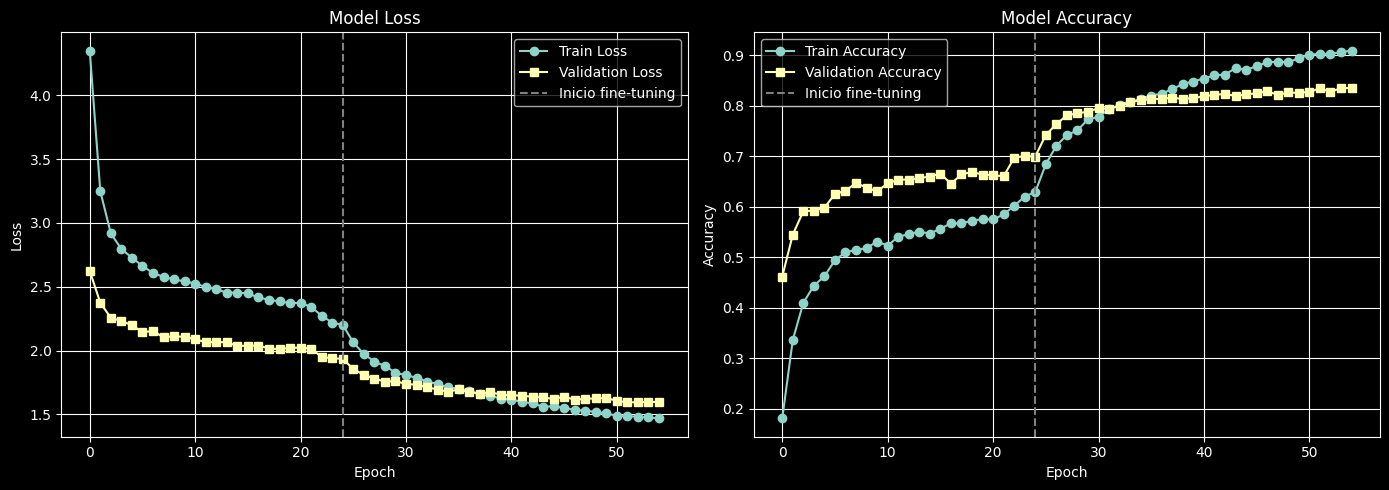

In [8]:
import matplotlib.pyplot as plt

# Combinamos el historial de las dos fases
train_loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']
train_accuracy = history.history['accuracy'] + history_fine.history['accuracy']
val_accuracy = history.history['val_accuracy'] + history_fine.history['val_accuracy']

n_fase1 = len(history.history['loss'])

# Crear figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
ax1.plot(train_loss, label='Train Loss', marker='o')
ax1.plot(val_loss, label='Validation Loss', marker='s')
ax1.axvline(n_fase1 - 1, color='gray', linestyle='--', label='Inicio fine-tuning')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Model Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de precisión
ax2.plot(train_accuracy, label='Train Accuracy', marker='o')
ax2.plot(val_accuracy, label='Validation Accuracy', marker='s')
ax2.axvline(n_fase1 - 1, color='gray', linestyle='--', label='Inicio fine-tuning')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Conclusiones

Hemos dado dos pasos para subir el accuracy por encima del 75% inicial:

1.  **Backbone más potente**: de `EfficientNetB0` (~5M params) a `EfficientNetV2S` (~21M params), con mucha más capacidad para la clasificación *fine-grained* de especies de aves.
2.  **Fine-tuning robusto**: congelando las capas `BatchNormalization`, monitorizando `val_accuracy` y con una red de seguridad que evita quedarnos con un modelo peor.

Si quieres seguir subiendo el accuracy, los siguientes niveles serían:

*   **Aumentar la resolución de entrada**: cambia `IMG_ROWS`/`IMG_COLS` a 300 o 384. Es el factor que más ayuda en problemas fine-grained, porque los detalles que distinguen especies son muy pequeños. Tendrás que bajar el `batch_size` (a 8 o menos) para que quepa en la GPU.
*   **Un backbone aún mayor**: `EfficientNetV2M` o `ConvNeXtBase`, aunque pueden no caber en 8 GB de VRAM durante el fine-tuning.
*   **Test-Time Augmentation (TTA)**: promediar las predicciones de varias versiones aumentadas de cada imagen al evaluar.

In [9]:
# Guardamos el modelo final (el mejor de las dos fases)
model.save('birds_final_v2.keras')
print('Modelo guardado como birds_final.keras')

Modelo guardado como birds_final.keras
